# 🚖 Ride Booking Data Analysis
### Customer Behavior, Cancellation Trends & Business Insights

---
## 📌 Project Overview

### 🎯 Objective
The objective of this project is to analyze ride booking data and identify key business insights related to booking performance, customer behavior, cancellation patterns, vehicle demand, revenue generation, and service quality.

### ❓ Business Problem
Ride-booking platforms handle thousands of bookings daily. Understanding why rides are cancelled, which vehicle types are most preferred, when demand peaks, and how customers interact with the platform can help improve operational efficiency and customer satisfaction.

---


## 📚 Import Libraries

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 📂 Data Loading

### Dataset Preview
---

In [3]:
df = pd.read_csv(r"C:\Users\DeLL\Desktop\Riding Analysis\rideBookings.csv")
df.head(10)


,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI
5,2024-02-06,09:44:56,"""CNR4096693""",Completed,"""CID4670564""",Auto,AIIMS,Narsinghpur,5.1,18.1,...,NaN,NaN,NaN,NaN,NaN,316.0,4.85,4.1,4.6,UPI
6,2024-06-17,15:45:58,"""CNR2002539""",Completed,"""CID6800553""",Go Mini,Vaishali,Punjabi Bagh,7.1,20.4,...,NaN,NaN,NaN,NaN,NaN,640.0,41.24,4.0,4.1,UPI
7,2024-03-19,17:37:37,"""CNR6568000""",Completed,"""CID8610436""",Auto,Mayur Vihar,Cyber Hub,12.1,16.5,...,NaN,NaN,NaN,NaN,NaN,136.0,6.56,4.4,4.2,UPI
8,2024-09-14,12:49:09,"""CNR4510807""",No Driver Found,"""CID7873618""",Go Sedan,Noida Sector 62,Noida Sector 18,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2024-12-16,19:06:48,"""CNR7721892""",Incomplete,"""CID5214275""",Auto,Rohini,Adarsh Nagar,6.1,26.0,...,NaN,NaN,NaN,1.0,Other Issue,135.0,10.36,NaN,NaN,Cash


### Dataset Information
---

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

--- 

## 🔍 Data Understanding

### Dataset Shape

The dataset contains 150,000 booking records and 21 features, covering ride details, booking status, vehicle information, payment methods, ratings, and cancellation reasons.

### Data Types

The dataset includes both numerical and categorical variables, allowing analysis of operational metrics, customer behavior, and business performance.


### Statistical Summary

Basic statistical analysis was performed to understand booking values, ride distances, customer ratings, and driver ratings.

---



## 🧹 Data Quality Assessment

### Missing Values Analysis


In [20]:
print("Missing Values :",df.isnull().sum())

Missing Values : Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Avg VTAT                              10500
Avg CTAT                              48000
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Incomplete Rides                     141000
Incomplete Rides Reason              141000
Booking Value                         48000
Ride Distance                         48000
Driver Ratings                        57000
Customer Rating                       57000
Payment Method                        48000
dtype: int64


### Duplicate Records Analysis

In [5]:
print("Duplicate Records :",df.duplicated().sum())

Duplicate Records : 0



### Missing Value Investigation

In [4]:
missing = df.isnull().sum()

missing_percent = (df.isnull().sum() / len(df)) * 100

print(pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percent.round(2)
}))

                                   Missing Values  Percentage
Date                                            0         0.0
Time                                            0         0.0
Booking ID                                      0         0.0
Booking Status                                  0         0.0
Customer ID                                     0         0.0
Vehicle Type                                    0         0.0
Pickup Location                                 0         0.0
Drop Location                                   0         0.0
Avg VTAT                                    10500         7.0
Avg CTAT                                    48000        32.0
Cancelled Rides by Customer                139500        93.0
Reason for cancelling by Customer          139500        93.0
Cancelled Rides by Driver                  123000        82.0
Driver Cancellation Reason                 123000        82.0
Incomplete Rides                           141000        94.0
Incomple


#### 💡 Insight

The missing values were not data quality issues but business-driven missing values caused by ride cancellations and incomplete bookings.

---

## 📊 Booking Performance Analysis


### Booking Status Distribution

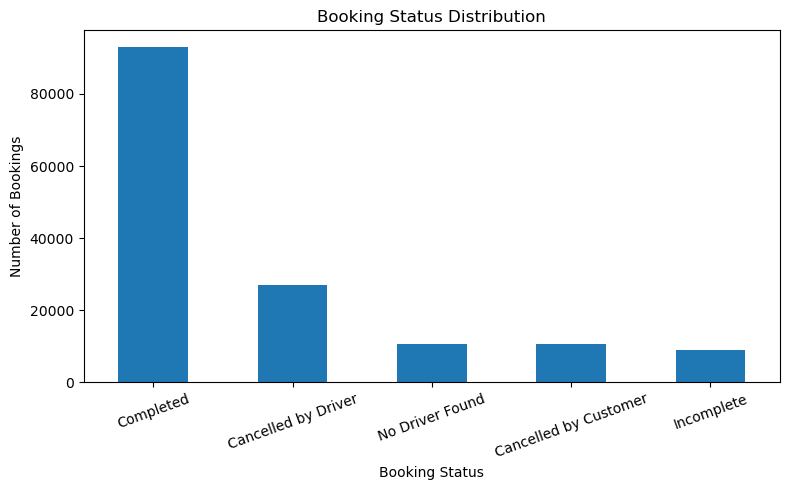

In [12]:
plt.figure(figsize=(8,5))

booking_status = df['Booking Status'].value_counts()

booking_status.plot(kind='bar')

plt.title('Booking Status Distribution')
plt.xlabel('Booking Status')
plt.ylabel('Number of Bookings')

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()


#### 💡 Insight

Although most rides were completed successfully, approximately 38% of bookings failed to reach completion. Driver cancellations emerged as the largest contributor to ride failures.

---

## 🚗 Vehicle Demand Analysis

### Vehicle Type Distribution


🚗 Vehicle Distribution Analysis

📌 Vehicle Distribution:
Vehicle Type
Auto             37419
Go Mini          29806
Go Sedan         27141
Bike             22517
Premier Sedan    18111
eBike            10557
Uber XL           4449
Name: count, dtype: int64

📌 Total Vehicles: 150000

📌 Vehicle Type Percentage:
Vehicle Type
Auto             24.95
Go Mini          19.87
Go Sedan         18.09
Bike             15.01
Premier Sedan    12.07
eBike             7.04
Uber XL           2.97
Name: count, dtype: float64


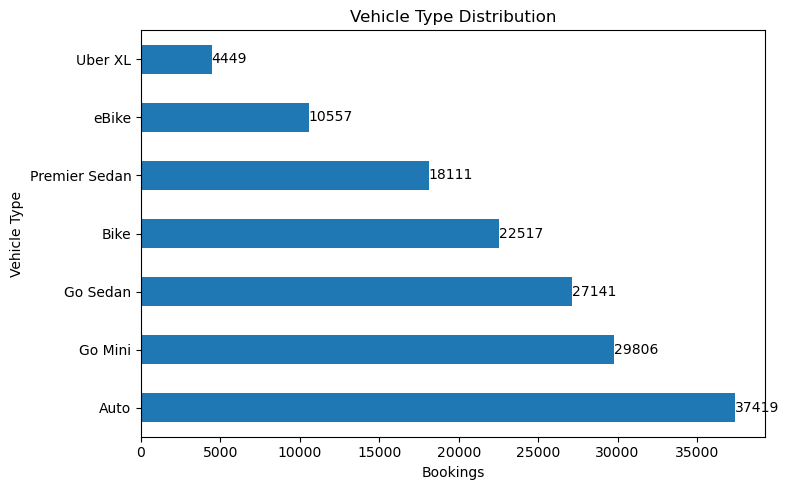

In [27]:
Vehicle_Type = df['Vehicle Type'].value_counts()
Total_vehicle = df['Vehicle Type'].count()
Precentage = (Vehicle_Type/Total_vehicle)*100
print("\n" + "="*50)
print("🚗 Vehicle Distribution Analysis")
print("="*50)

print("\n📌 Vehicle Distribution:")
print(Vehicle_Type)

print(f"\n📌 Total Vehicles: {Total_vehicle}")

print("\n📌 Vehicle Type Percentage:")
print(Precentage.round(2))


plt.figure(figsize=(8,5))

ax = df['Vehicle Type'].value_counts().plot(kind='barh')

plt.title('Vehicle Type Distribution')
plt.xlabel('Bookings')
plt.ylabel('Vehicle Type')

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()





#### 💡 Insight

Auto vehicles represent nearly one-fourth of all bookings, making them the most demanded service category.

---

## 💳 Payment Method Analysis

### Payment Method Distribution

💳 Payment Method Analysis

Total Payment Records : 102000

Payment Method Counts:
Payment Method
UPI            45909
Cash           25367
Uber Wallet    12276
Credit Card    10209
Debit Card      8239
Name: count, dtype: int64

Payment Method Percentage:
Payment Method
UPI            45.01
Cash           24.87
Uber Wallet    12.04
Credit Card    10.01
Debit Card      8.08
Name: count, dtype: float64


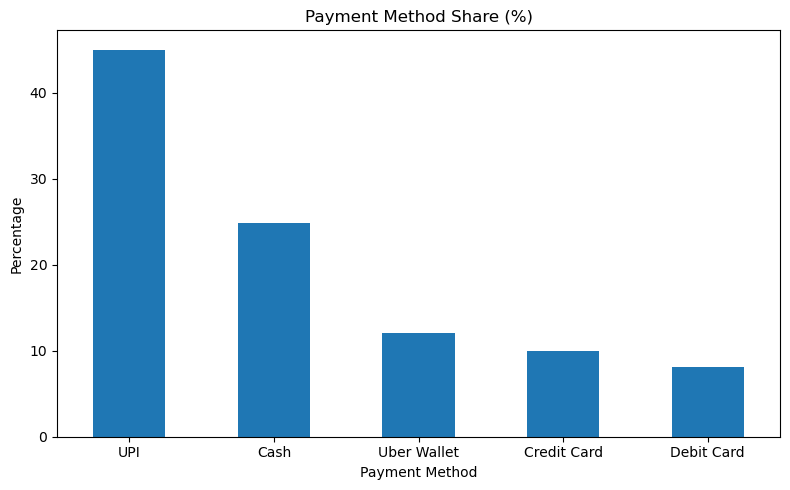

In [34]:
Payment_Methods = df['Payment Method'].value_counts()

Total_payment = Payment_Methods.sum()

Precentage = (Payment_Methods/Total_payment)*100

print("="*50)
print("💳 Payment Method Analysis")
print("="*50)

print(f"\nTotal Payment Records : {Total_payment}")

print("\nPayment Method Counts:")
print(Payment_Methods)

print("\nPayment Method Percentage:")
print(Precentage.round(2))


plt.figure(figsize=(8,5))

Precentage.plot(kind='bar')

plt.title('Payment Method Share (%)')
plt.xlabel('Payment Method')
plt.ylabel('Percentage')

plt.xticks(rotation=0)
plt.tight_layout()

plt.show()



#### 💡 Insight

UPI is the preferred payment method, indicating strong adoption of digital payments among customers.

---

## 💰 Revenue Analysis

### Average Booking Value

In [32]:
Avg_Booking = df['Booking Value'].mean()
print(f"💰 Average Booking Value: ₹{Avg_Booking:.2f}")

💰 Average Booking Value: ₹508.30


### Revenue by Vehicle Type


💰 Revenue Analysis by Vehicle Type

Total Revenue : ₹51,846,183.00

Revenue by Vehicle Type:
Vehicle Type
Auto             12878422.0
Bike              7837697.0
Go Mini          10338496.0
Go Sedan          9369719.0
Premier Sedan     6275332.0
Uber XL           1528032.0
eBike             3618485.0
Name: Booking Value, dtype: float64

Revenue Contribution Percentage:
Vehicle Type
Auto             24.84
Bike             15.12
Go Mini          19.94
Go Sedan         18.07
Premier Sedan    12.10
Uber XL           2.95
eBike             6.98
Name: Booking Value, dtype: float64


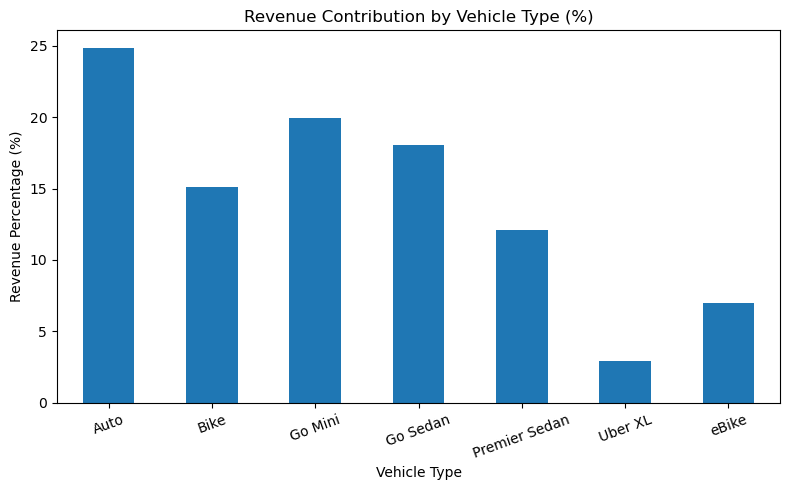

In [39]:
Vehicle_Revenue = df.groupby('Vehicle Type')['Booking Value'].sum()

Total_revenue = Vehicle_Revenue.sum()

Percentage_revenue = (Vehicle_Revenue / Total_revenue) * 100

print("="*50)
print("💰 Revenue Analysis by Vehicle Type")
print("="*50)

print(f"\nTotal Revenue : ₹{Total_revenue:,.2f}")

print("\nRevenue by Vehicle Type:")
print(Vehicle_Revenue.round(2))

print("\nRevenue Contribution Percentage:")
print(Percentage_revenue.round(2))

# Chart

plt.figure(figsize=(8,5))

Percentage_revenue.plot(kind='bar')

plt.title('Revenue Contribution by Vehicle Type (%)')
plt.xlabel('Vehicle Type')
plt.ylabel('Revenue Percentage (%)')

plt.xticks(rotation=20)
plt.tight_layout()

plt.show()

#### 💡 Insight

The platform primarily handles medium-value rides, indicating a balanced mix of affordability and revenue generation.

---

## 📏 Ride Distance Analysis

### Ride Distance Distribution

📏 Ride Distance Analysis

Average Ride Distance : 24.64 km


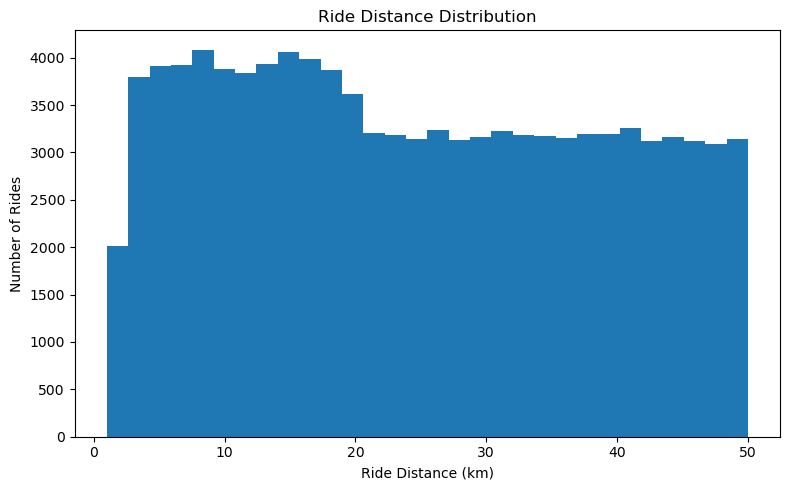

In [48]:
Avg_Distance = df['Ride Distance'].mean()

print("="*50)
print("📏 Ride Distance Analysis")
print("="*50)

print(f"\nAverage Ride Distance : {Avg_Distance:.2f} km")

plt.figure(figsize=(8,5))

df['Ride Distance'].dropna().plot(kind='hist', bins=30)

plt.title('Ride Distance Distribution')
plt.xlabel('Ride Distance (km)')
plt.ylabel('Number of Rides')

plt.tight_layout()
plt.show()



#### 💡 Insight 

The average ride distance is 24.64 km, suggesting that the platform is commonly used for medium-distance travel.

---


## ⭐ Customer Satisfaction Analysis

### Driver Rating Analysis

⭐ Driver Rating Analysis

Average Driver Rating : 4.23


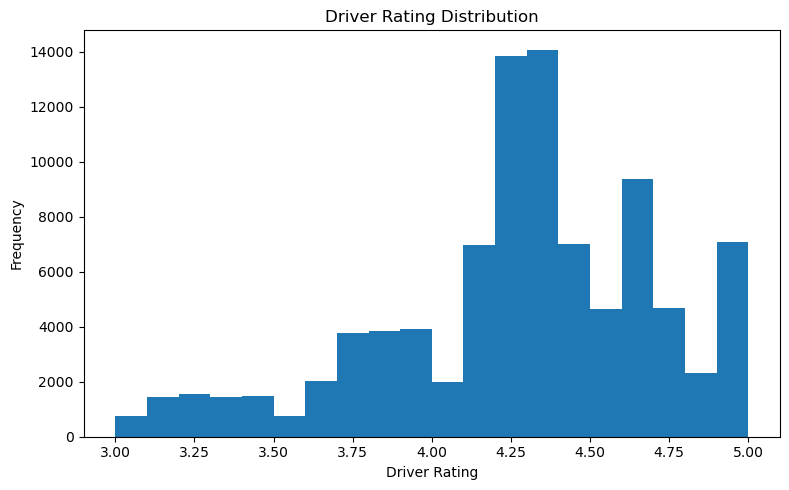

In [46]:
Avg_Driver = df['Driver Ratings'].mean()

print("="*50)
print("⭐ Driver Rating Analysis")
print("="*50)

print(f"\nAverage Driver Rating : {Avg_Driver:.2f}")

plt.figure(figsize=(8,5))

df['Driver Ratings'].dropna().plot(kind='hist', bins=20)

plt.title('Driver Rating Distribution')
plt.xlabel('Driver Rating')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


### Customer Rating Analysis

⭐ Customer Rating Analysis

Average Customer Rating : 4.40


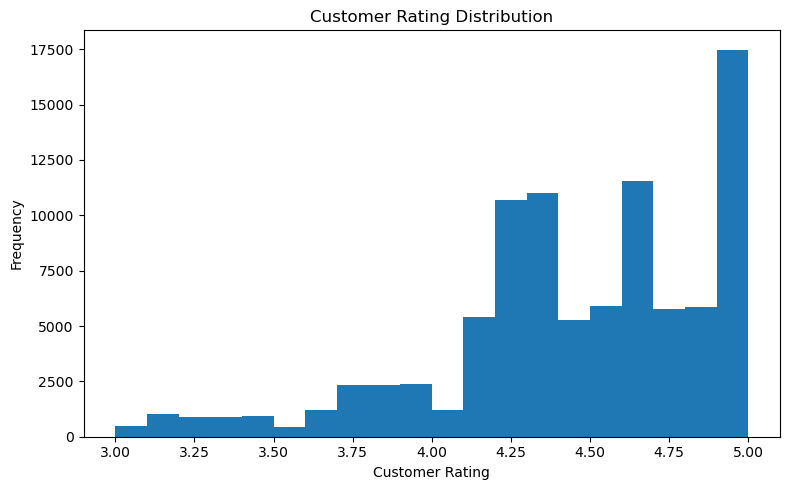

In [47]:

Avg_Customer = df['Customer Rating'].mean()

print("="*50)
print("⭐ Customer Rating Analysis")
print("="*50)

print(f"\nAverage Customer Rating : {Avg_Customer:.2f}")

plt.figure(figsize=(8,5))

df['Customer Rating'].dropna().plot(kind='hist', bins=20)

plt.title('Customer Rating Distribution')
plt.xlabel('Customer Rating')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

#### 💡 Insight 

High average ratings for both drivers (4.23) and customers (4.40) suggest strong service quality, healthy customer-driver interactions, and overall satisfaction with the ride experience.

---

## ❌ Cancellation Analysis

### Customer Cancellation Reasons


❌ Customer Cancellation Reasons
Reason for cancelling by Customer
Wrong Address                                   2362
Change of plans                                 2353
Driver is not moving towards pickup location    2335
Driver asked to cancel                          2295
AC is not working                               1155
Name: count, dtype: int64


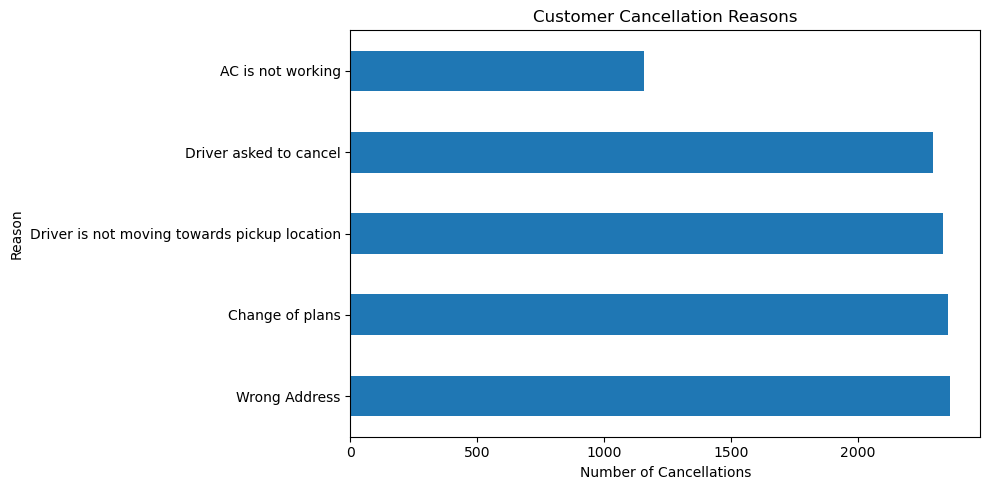

In [53]:
customer_cancelled = df[df['Booking Status'] == 'Cancelled by Customer']

print("="*50)
print("❌ Customer Cancellation Reasons")
print("="*50)

print(customer_cancelled['Reason for cancelling by Customer'].value_counts())


plt.figure(figsize=(10,5))

customer_cancelled['Reason for cancelling by Customer'] \
.value_counts() \
.plot(kind='barh')

plt.title('Customer Cancellation Reasons')
plt.xlabel('Number of Cancellations')
plt.ylabel('Reason')

plt.tight_layout()
plt.show()

### Driver Cancellation Reasons

🚫 Driver Cancellation Reasons
Driver Cancellation Reason
Customer related issue                 6837
The customer was coughing/sick         6751
Personal & Car related issues          6726
More than permitted people in there    6686
Name: count, dtype: int64


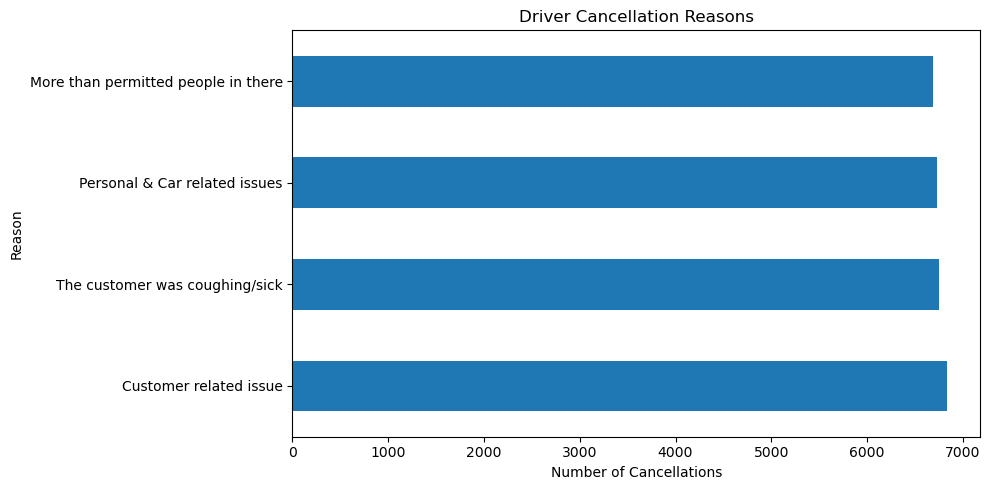

In [55]:
driver_cancelled = df[df['Booking Status'] == 'Cancelled by Driver']

print("="*50)
print("🚫 Driver Cancellation Reasons")
print("="*50)

print(driver_cancelled['Driver Cancellation Reason'].value_counts())


plt.figure(figsize=(10,5))

driver_cancelled['Driver Cancellation Reason'] \
.value_counts() \
.plot(kind='barh')

plt.title('Driver Cancellation Reasons')
plt.xlabel('Number of Cancellations')
plt.ylabel('Reason')

plt.tight_layout()
plt.show()

### Incomplete Ride Reasons

⚠️ Incomplete Ride Reasons
Incomplete Rides Reason
Customer Demand      3040
Vehicle Breakdown    3012
Other Issue          2948
Name: count, dtype: int64


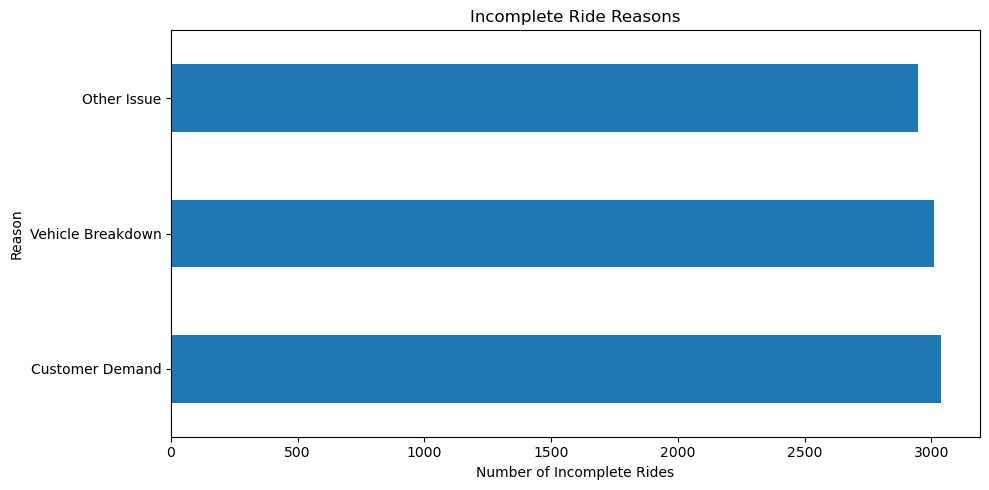

In [56]:
Incomplete_ride = df[df['Booking Status'] == 'Incomplete']

print("="*50)
print("⚠️ Incomplete Ride Reasons")
print("="*50)

print(Incomplete_ride['Incomplete Rides Reason'].value_counts())

plt.figure(figsize=(10,5))

Incomplete_ride['Incomplete Rides Reason'] \
.value_counts() \
.plot(kind='barh')

plt.title('Incomplete Ride Reasons')
plt.xlabel('Number of Incomplete Rides')
plt.ylabel('Reason')

plt.tight_layout()
plt.show()

#### 💡 Insight

Driver-related cancellations represent the largest source of booking failures, while customer cancellations are mainly caused by planning and location-related issues. Additionally, vehicle breakdowns and operational challenges contribute to incomplete rides. Reducing driver cancellations and improving operational efficiency could significantly improve overall ride completion rates.

---

## 📍 Location Analysis

### Top Pickup Locations

📍 Top 10 Pickup Locations
Pickup Location
Khandsa             949
Barakhamba Road     946
Saket               931
Badarpur            921
Pragati Maidan      920
Madipur             919
AIIMS               918
Mehrauli            915
Dwarka Sector 21    914
Pataudi Chowk       907
Name: count, dtype: int64


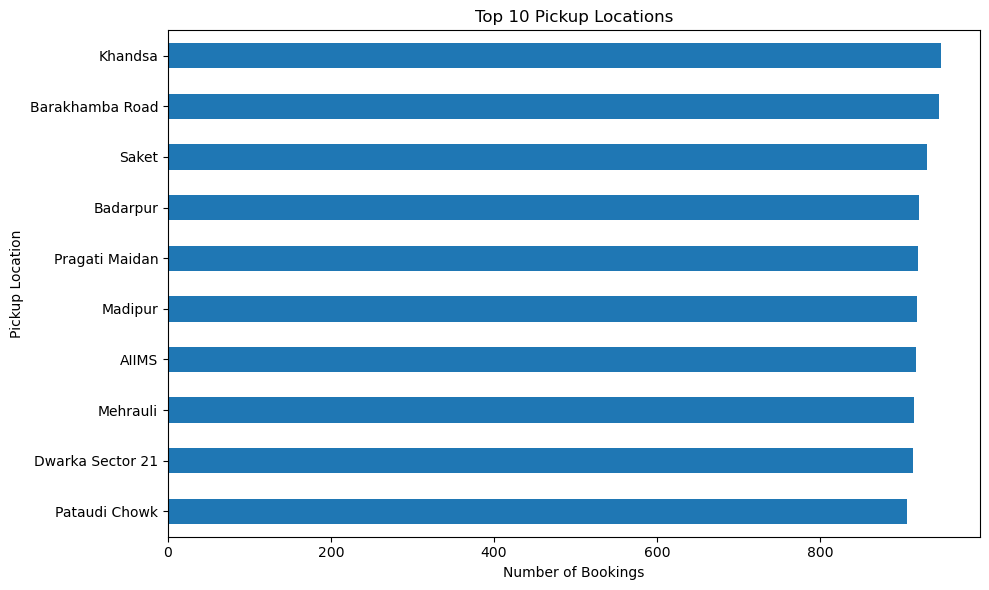

In [60]:
Top_Pickup = df['Pickup Location'].value_counts().head(10)

print("="*50)
print("📍 Top 10 Pickup Locations")
print("="*50)

print(Top_Pickup)

plt.figure(figsize=(10,6))

Top_Pickup.sort_values().plot(kind='barh')

plt.title('Top 10 Pickup Locations')
plt.xlabel('Number of Bookings')
plt.ylabel('Pickup Location')

plt.tight_layout()
plt.show()


### Top Drop Locations

📍 Top 10 Drop Locations
Drop Location
Ashram                936
Basai Dhankot         917
Lok Kalyan Marg       916
Narsinghpur           913
Cyber Hub             912
Kalkaji               912
Kashmere Gate ISBT    909
Udyog Vihar           906
Lajpat Nagar          904
Nehru Place           902
Name: count, dtype: int64


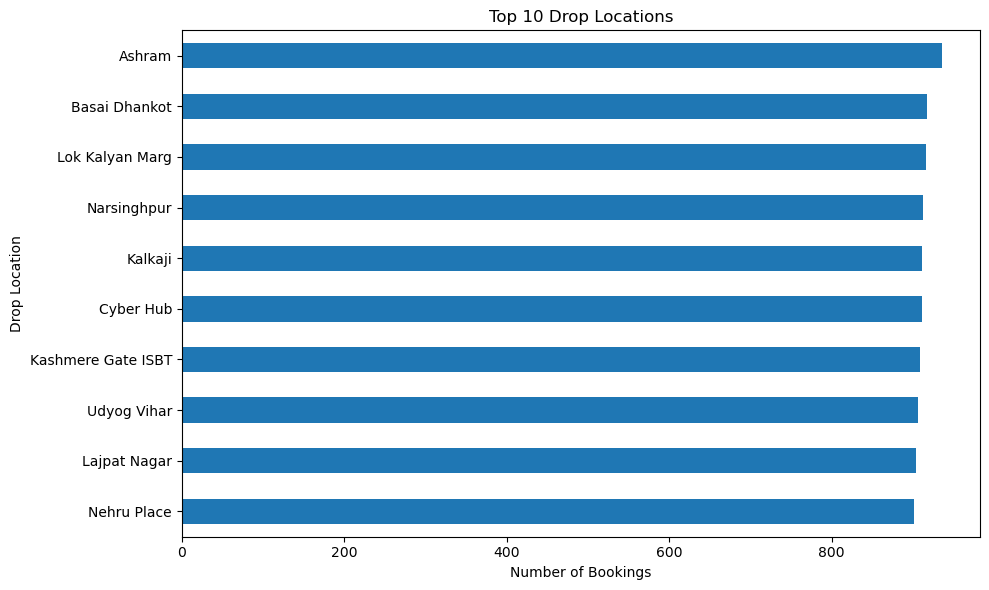

In [63]:
Top_Drop = df['Drop Location'].value_counts().head(10)

print("="*50)
print("📍 Top 10 Drop Locations")
print("="*50)

print(Top_Drop)

plt.figure(figsize=(10,6))

Top_Drop.sort_values().plot(kind='barh')

plt.title('Top 10 Drop Locations')
plt.xlabel('Number of Bookings')
plt.ylabel('Drop Location')

plt.tight_layout()
plt.show()

#### 💡 Insight

The analysis reveals that a small number of locations account for a significant share of ride demand. Areas such as Khandsa, Barakhamba Road, and Saket emerge as major pickup hubs, while Ashram, Basai Dhankot, and Cyber Hub are among the most frequent drop destinations. These locations represent key demand hotspots across the platform.

---

## ⏰ Time Analysis


### Peak Booking Hours





⏰ Peak Booking Hours
Hour
0      1373
1      1360
2      1339
3      1383
4      1321
5      2786
6      4160
7      5450
8      6861
9      8234
10     9577
11     8390
12     7006
13     5470
14     7031
15     8202
16     9633
17    11044
18    12397
19    11047
20     9630
21     8103
22     5441
23     2762
Name: count, dtype: int64


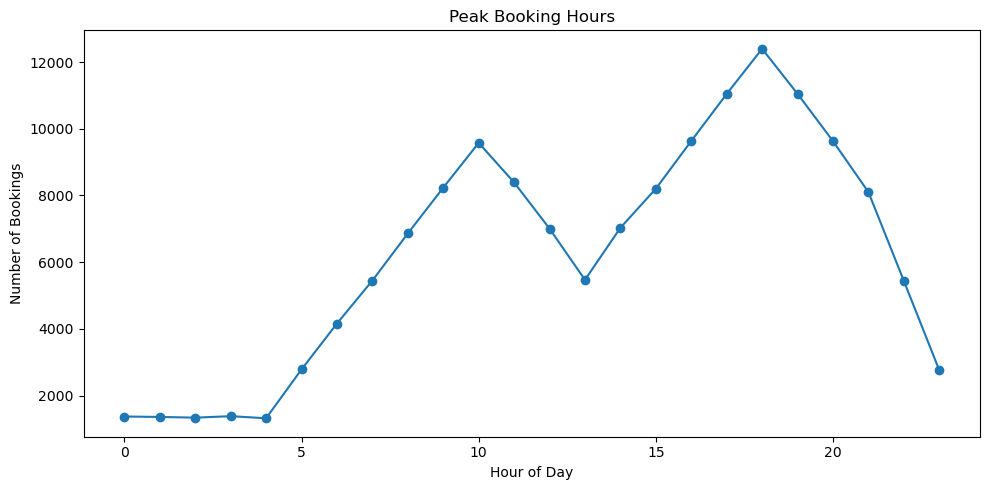

In [71]:
# Convert Time column into datetime
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S')

# Extract Hour
df['Hour'] = df['Time'].dt.hour

# Create Time Period Column
def time_period(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df['Time Period'] = df['Hour'].apply(time_period)

# ================= Peak Booking Hours =================

peak_hours = df['Hour'].value_counts().sort_index()

print("="*50)
print("⏰ Peak Booking Hours")
print("="*50)
print(peak_hours)

# Chart
plt.figure(figsize=(10,5))

peak_hours.plot(kind='line', marker='o')

plt.title('Peak Booking Hours')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Bookings')

plt.tight_layout()
plt.show()

### Time Period Analysis


🌅 Time Period Analysis
Time Period
Morning      45458
Evening      44118
Afternoon    37342
Night        23082
Name: count, dtype: int64


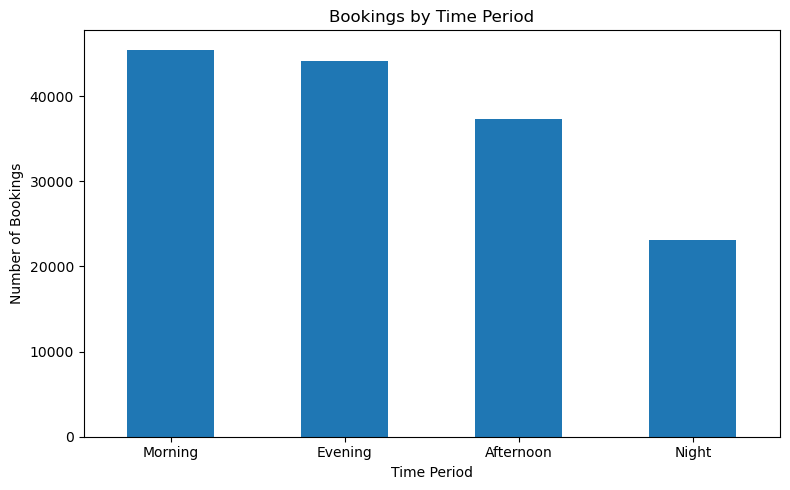

In [72]:
time_period_analysis = df['Time Period'].value_counts()

print("\n" + "="*50)
print("🌅 Time Period Analysis")
print("="*50)
print(time_period_analysis)

# Chart
plt.figure(figsize=(8,5))

time_period_analysis.plot(kind='bar')

plt.title('Bookings by Time Period')
plt.xlabel('Time Period')
plt.ylabel('Number of Bookings')

plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

#### 💡 Insight

Morning (45,458 bookings) and Evening (44,118 bookings) are the busiest periods of the day, indicating strong demand during daily commuting hours. The highest booking volume occurs around 6 PM, making it the peak booking hour.


---

## 📈 Key Findings

### Major Findings

- The platform processed 150,000 bookings.
- Booking completion rate was 62%.
- Driver cancellations accounted for 18% of all bookings.
- Auto was the most preferred vehicle type.
- UPI was the most frequently used payment method.
- Average booking value was ₹508.30.
- Average ride distance was 24.64 km.
- Customer satisfaction remained high with ratings above 4 stars.

---

## 🚀 Recommendations

- Reduce driver cancellation rates. 
- Improve driver availability during peak hours.
- Expand Auto and Go Mini fleets.
- Promote digital payment adoption.
- Optimize driver allocation in high-demand locations.
- Monitor cancellation reasons regularly.
- Maintain service quality through rating-based performance tracking.


---





## 🏁 Conclusion
### Final Summary
This analysis provided valuable insights into ride booking operations, customer preferences, and service performance. While customer satisfaction and demand remain strong, driver cancellations represent a significant operational challenge. By improving driver availability, reducing cancellations, and optimizing fleet allocation, the platform can improve booking completion rates and enhance the overall customer experience.